<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [24]:
# Import torch
import torch
from tensorflow.python.ops.gen_logging_ops import tensor_summary

# Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"

# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors. 
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [25]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

n_samples =1000

X,y = make_moons(
    n_samples=n_samples,
    noise=0.2,
    random_state=RANDOM_SEED
)

In [26]:
# Turn data into a DataFrame
import pandas as pd

moons = pd.DataFrame({
    "X1": X[:, 0],  # 第一列特征
    "X2": X[:, 1],  # 第二列特征
    "y": y          # 标签（0/1两类）
})

moons.head(10)

,X1,X2,y
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0
5,0.662510,-0.084356,1
6,0.274510,-0.189904,1
7,-0.115556,0.535912,1
8,1.572369,-0.335447,1
9,0.763990,0.962359,0


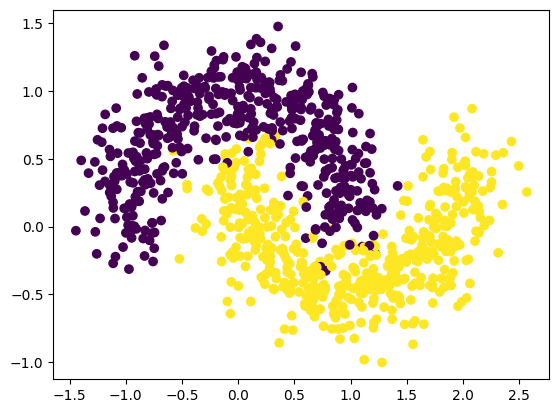

In [27]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.scatter(
    X[:, 0], X[:, 1], c=y
)

In [28]:
# Turn data into tensors of dtype float
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=RANDOM_SEED
)

X_train.shape, X_test.shape,y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [29]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    ## Your code here ##
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, 8)
        self.layer_5 = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        x = self.relu(x)
        x = self.layer_4(x)
        x = self.relu(x)
        x = self.layer_5(x)
        return  x

# Instantiate the model
## Your code here ##
model_0 = MoonModelV0().to(device)

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [30]:
# Setup loss function
loss_fn = torch.nn.BCEWithLogitsLoss()
# Setup optimizer to optimize model's parameters
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [31]:
# What's coming out of our model?
X_train,X_test,y_train,y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)
# logits (raw outputs of model)
print("Logits:")
## Your code here ##
logits = model_0(X_train).squeeze()
print(logits[:5])
# Prediction probabilities
print("Pred probs:")
## Your code here ##
prods = torch.sigmoid(model_0(X_train)).squeeze()
print(prods[:5])
# Prediction labels
print("Pred labels:")
## Your code here ##
labels = torch.round(torch.sigmoid(model_0(X_train)).squeeze())
print(labels[:5])

Logits:
tensor([-0.0012, -0.0206,  0.0108,  0.0056, -0.0174], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred probs:
tensor([0.4997, 0.4948, 0.5027, 0.5014, 0.4956], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred labels:
tensor([0., 0., 1., 1., 0.], device='cuda:0', grad_fn=<SliceBackward0>)


In [32]:

from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="binary").to(device)
# send accuracy function to device
acc_fn

BinaryAccuracy()

In [33]:
## TODO: Uncomment this to set the seed
torch.manual_seed(RANDOM_SEED)

# Setup epochs
epochs = 1000

# Send data to the device
X_train,X_test,y_train,y_test=X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

# Loop through the data
for epoch in range(epochs):
  ### Training
  # 1. Forward pass (logits output)
  y_logits = model_0(X_train).squeeze()
  # Turn logits into prediction probabilities
  y_pred = torch.sigmoid(y_logits).squeeze()
  # Turn prediction probabilities into prediction labels
  y_labels =torch.round(y_pred)

  # 2. Calculaute the loss
  loss = loss_fn(y_logits, y_train)
  # loss = compare model raw outputs to desired model outputs

  # Calculate the accuracy
  acc = acc_fn(y_logits, y_train.int())
  # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  optimizer.zero_grad()

  # 4. Loss backward (perform backpropagation) - https://brilliant.org/wiki/backpropagation/#:~:text=Backpropagation%2C%20short%20for%20%22backward%20propagation,to%20the%20neural%20network's%20weights.
  loss.backward()
  
  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression) 
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass (to get the logits)
    test_logits = model_0(X_test).squeeze()
    # Turn the test logits into prediction labels
    test_pred = torch.round(torch.sigmoid(test_logits)).squeeze()

    # 2. Caculate the test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_pred, y_test.long())

  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"epoch: {epoch}, loss: {loss:.4f}, acc: {acc:.4f}")

epoch: 0, loss: 0.6962, acc: 0.3088
epoch: 100, loss: 0.2461, acc: 0.8888
epoch: 200, loss: 0.0847, acc: 0.9712
epoch: 300, loss: 0.0640, acc: 0.9750
epoch: 400, loss: 0.0604, acc: 0.9762
epoch: 500, loss: 0.0581, acc: 0.9775
epoch: 600, loss: 0.0556, acc: 0.9800
epoch: 700, loss: 0.0536, acc: 0.9775
epoch: 800, loss: 0.0519, acc: 0.9800
epoch: 900, loss: 0.0508, acc: 0.9800


## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [34]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

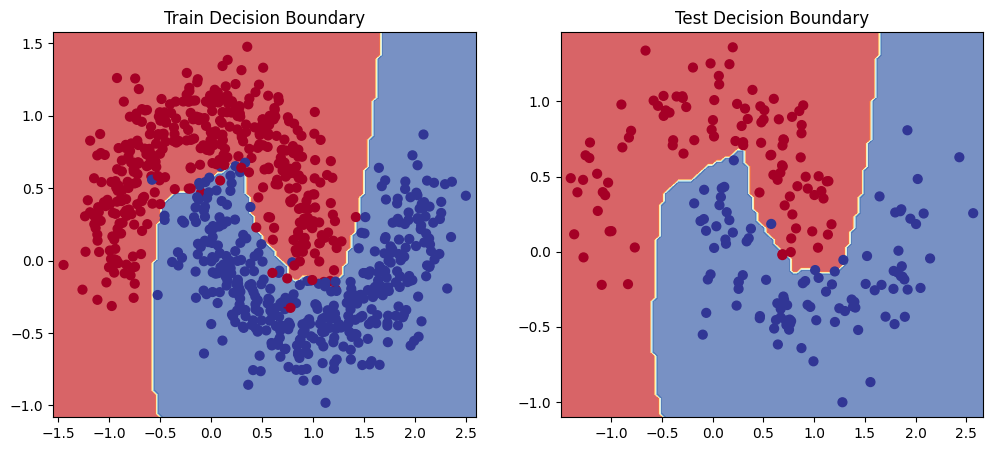

In [35]:
# Plot decision boundaries for training and test sets
# 创建一个 1 行 2 列的画布，方便对比训练集和测试集的决策边界
plt.figure(figsize=(12, 5))

# 左图：训练集决策边界
plt.subplot(1, 2, 1)
plot_decision_boundary(model_0, X_train, y_train)  # 用训练好的模型在训练集上画分类边界
plt.title("Train Decision Boundary")

# 右图：测试集决策边界
plt.subplot(1, 2, 2)
plot_decision_boundary(model_0, X_test, y_test)    # 用同一个模型在测试集上画分类边界
plt.title("Test Decision Boundary")

# 显示图像
plt.show()

## 6. 使用纯 PyTorch 复现 Tanh（双曲正切）激活函数。
  * 你可以参考 [ML cheatsheet 网站](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) 中的公式。

In [36]:
# Create a straight line tensor
tensor_straight = torch.arange(0,10,0.1)

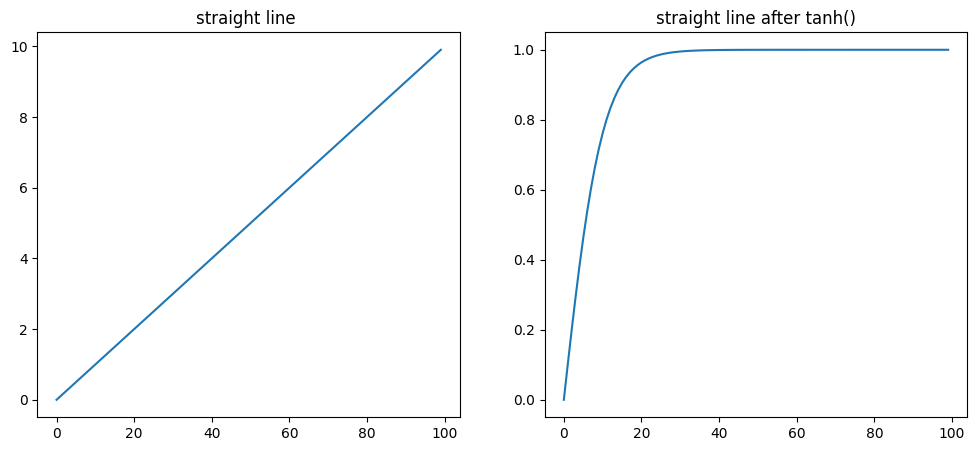

In [37]:
# Test torch.tanh() on the tensor and plot it
import matplotlib.pyplot as plt
tensor_s_preds = torch.tanh(tensor_straight)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tensor_straight)
plt.title("straight line ")
plt.subplot(1, 2, 2)
plt.plot(tensor_s_preds)
plt.title("straight line after tanh()")
plt.show()

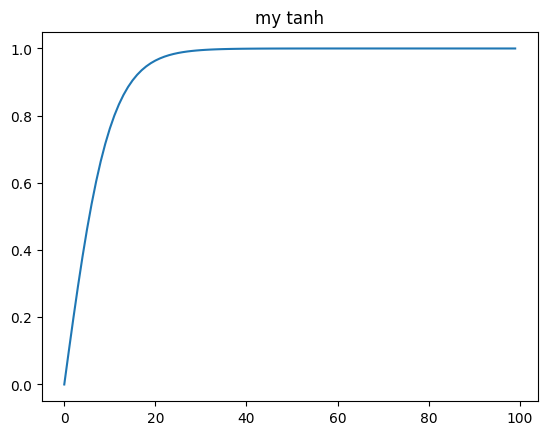

In [38]:
# Replicate torch.tanh() and plot it
def tanhReplicate(x):
    return (torch.exp(x)-torch.exp(-x))/(torch.exp(x)+torch.exp(-x))
plt.plot(tanhReplicate(tensor_straight))
plt.title("my tanh")
plt.show()

## 7. 使用 [CS231n 的螺旋数据生成函数](https://cs231n.github.io/neural-networks-case-study/) 创建一个多分类数据集（下方提供了代码）。
  * 将数据划分为训练集和测试集（80% 训练，20% 测试），并转换为 PyTorch 张量。
  * 构建一个能够拟合该数据的模型（你可能需要线性层与非线性层的组合）。
  * 构建可处理多分类数据的损失函数和优化器（可选扩展：使用 Adam 替代 SGD，可能需要尝试不同学习率）。
  * 为多分类数据编写训练与测试循环，并将模型训练到测试准确率超过 95%（可使用任意准确率计算函数）——1000 个 epoch 通常足够。
  * 基于模型预测结果在螺旋数据集上绘制决策边界，`plot_decision_boundary()` 函数在该数据集上也应可用。

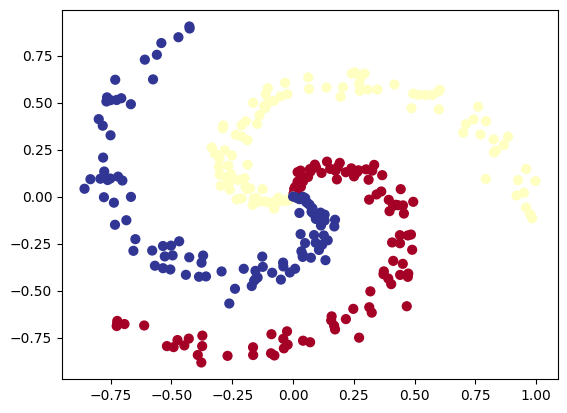

In [39]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [40]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([240, 2]),
 torch.Size([240]),
 torch.Size([60, 2]),
 torch.Size([60]))

In [41]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics --user
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device)
acc_fn

MulticlassAccuracy()

In [42]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class spiralModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(2,64)
        self.layer_2=nn.Linear(64,32)
        self.layer_3=nn.Linear(32,8)
        self.layer_4=nn.Linear(8,3)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        x = self.layer_4(x)
        return x

# Instantiate model and send it to device
model_1 = spiralModel().to(device)

In [43]:
# Setup data to be device agnostic
X_train,X_test,y_train,y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
## Your code here ##
print(model_1(X_train).squeeze()[:5])
print("Pred probs:")
## Your code here ##
print(torch.softmax(model_1(X_test).squeeze(),dim = 1)[:5])
print("Pred labels:")
## Your code here ##
print(torch.softmax(model_1(X_test).squeeze(),dim = 1).argmax(dim = 1))

Logits:
tensor([[-0.1211,  0.2292,  0.2632],
        [-0.1114,  0.2286,  0.2698],
        [-0.1326,  0.2322,  0.2563],
        [-0.1298,  0.2191,  0.2509],
        [-0.1352,  0.2198,  0.2584]], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.2557, 0.3674, 0.3769],
        [0.2578, 0.3683, 0.3738],
        [0.2525, 0.3699, 0.3776],
        [0.2552, 0.3680, 0.3768],
        [0.2571, 0.3651, 0.3778]], device='cuda:0', grad_fn=<SliceBackward0>)
Pred labels:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [44]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [45]:
# Build a training loop for the model
epochs = 1000
# Loop over data

for epoch in range(epochs):
  ## Training
  model_1.train()
  # 1. Forward pass
  model_1(X_train)

  # 2. Calculate the loss
  loss = loss_fn(model_1(X_train), y_train)
  
  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    model_1(X_test)
    # 2. Caculate loss and acc
    loss = loss_fn(model_1(X_test), y_test)
    acc = acc_fn(model_1(X_test), y_test)
  # Print out what's happening every 100 epochs
  if epoch%100 == 0:
      print(f"epoch: {epoch}, loss: {loss:.4f}, acc: {acc:.4f}")


epoch: 0, loss: 1.1168, acc: 0.3667
epoch: 100, loss: 0.7274, acc: 0.5833
epoch: 200, loss: 0.3174, acc: 0.9333
epoch: 300, loss: 0.1095, acc: 1.0000
epoch: 400, loss: 0.0460, acc: 1.0000
epoch: 500, loss: 0.0258, acc: 1.0000
epoch: 600, loss: 0.0162, acc: 1.0000
epoch: 700, loss: 0.0104, acc: 1.0000
epoch: 800, loss: 0.0067, acc: 1.0000
epoch: 900, loss: 0.0043, acc: 1.0000


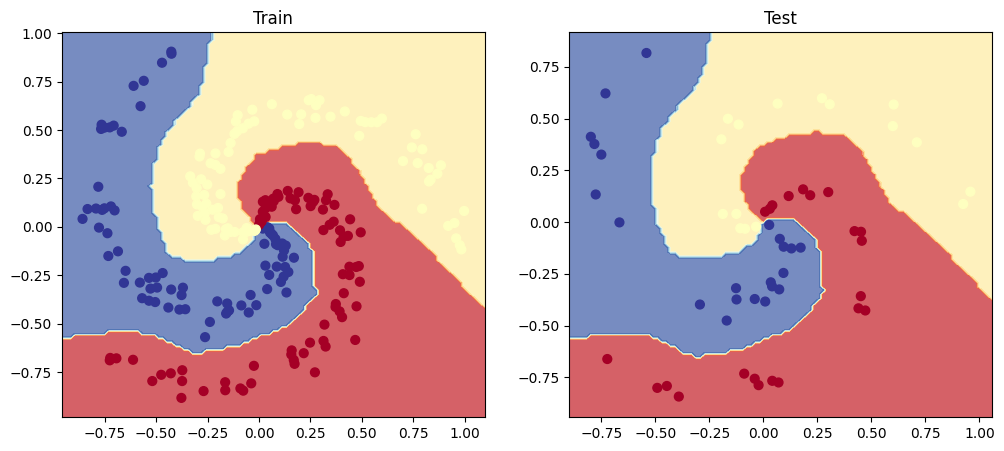

In [46]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_1, X_train, y_train)
plt.title("Train")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_1, X_test, y_test)
plt.title("Test")

plt.show()